In [26]:
import pickle
import numpy as np
import pandas as pd
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [6]:
lat = np.arange(-90, 90, 180/192)
lon = np.arange(0, 360, 360/288)

lat_bnd1 = np.where(lat==10.3125)[0][0]
lat_bnd2 = np.where(lat==50.625)[0][0]
lon_bnd1 = np.where(lon==210)[0][0]
lon_bnd2 = np.where(lon==300)[0][0]

In [7]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

with open(f'{base_path}/Data/ERA5/Final/X_era5.pkl', "rb") as f:
    x = pickle.load(f)
    
x = np.transpose(np.array(x), (0, 2, 3, 1))

x = x[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]

x_test_era5 = x[8000:]
x_all_era5 = x

In [9]:
da = xr.DataArray(
    x, dims=['sample', 'lat', 'lon', 'var'],
    coords={'lat': lat[lat_bnd1:lat_bnd2],
            'lon': lon[lon_bnd1:lon_bnd2]})
da

<xarray.DataArray (sample: 9982, lat: 43, lon: 72, var: 3)> Size: 742MB
array([[[[ 1.02938739, -1.31859424, -1.02539582],
         [ 1.14914529, -1.23998018, -1.10542336],
         [ 1.25707489, -1.2018358 , -1.09283446],
         ...,
         [ 0.18266134, -1.20305598, -0.82789583],
         [ 0.05985786, -1.12248766,  0.76498605],
         [ 0.85708435, -1.03630101,  0.03340736]],

        [[ 1.26258124, -1.33128998, -1.17395477],
         [ 1.39643438, -1.24006761, -1.20493482],
         [ 1.49271244, -1.16561877, -1.04907142],
         ...,
         [ 0.4282957 , -1.27385797, -0.1742238 ],
         [ 0.05405072, -1.20518392,  0.45340255],
         [-0.41828703, -1.11856542,  0.6553578 ]],

        [[ 1.52262646, -1.33975642, -1.33173721],
         [ 1.67316173, -1.22328189, -1.25307946],
         [ 1.76216378, -1.12088504, -1.00742492],
         ...,
...
         ...,
         [ 1.45922498,  1.00670951,  0.758597  ],
         [ 1.32819301,  1.046071  ,  0.57746638],
         [ 1.11957387,  1.06716791,  0.3890148 ]],

        [[-0.83450593, -0.94142728,  0.43936513],
         [-0.86525391, -0.82777946,  0.35537452],
         [-0.79993783, -0.68487345,  0.28840562],
         ...,
         [ 1.36524103,  0.94180527,  0.61590994],
         [ 1.21971292,  0.97544693,  0.55580671],
         [ 1.01160519,  0.98910414,  0.41582954]],

        [[-0.8027601 , -0.91915718,  0.41779592],
         [-0.80485807, -0.80648546,  0.3254106 ],
         [-0.70381026, -0.66490712,  0.29468449],
         ...,
         [ 1.13371738,  0.9083266 ,  0.47678164],
         [ 1.02152674,  0.93406156,  0.47134224],
         [ 0.82478768,  0.94011165,  0.45245487]]]])
Coordinates:
  * lat      (lat) float64 344B 10.31 11.25 12.19 13.12 ... 47.81 48.75 49.69
  * lon      (lon) float64 576B 210.0 211.2 212.5 213.8 ... 296.2 297.5 298.8
Dimensions without coordinates: sample, var

In [20]:
# Center the data (subtract mean across spatial domain per sample)
da_prime = da - da.mean(dim=['lat', 'lon'])

# Correlate grid points with their immediate neighbors along longitude (lag=1)
spatial_corr_lon = xr.corr(da_prime, da_prime.shift(lon=15), dim=['lat', 'lon'])

# spatial_corr_lon is now a 1D array of shape (n_vars,) across all samples!
print(spatial_corr_lon.values)

[[-0.02159264  0.08702109  0.09588527]
 [-0.00804717 -0.01732257  0.15123692]
 [ 0.03939615 -0.05757039  0.17366525]
 ...
 [ 0.10995449  0.42995291  0.26045459]
 [ 0.0877947   0.6753629   0.33035157]
 [ 0.19387416  0.55994677  0.37599656]]


In [21]:
np.mean(spatial_corr_lon, axis=0).values

array([0.00510703, 0.18315144, 0.10979114])

In [24]:
# Assuming 'da' is your DataArray of shape (sample, lat, lon, var)
# Pre-center the data across the spatial domain for each sample
da_prime = da - da.mean(dim=['lat', 'lon'])

max_lag = 10  # Adjust based on grid resolution
lags = list(range(1, max_lag + 1))

# Compute correlation across all samples for each lag value
corrs_list = []
for lag in lags:
  
    corr_at_lag = xr.corr(da_prime, da_prime.shift(lon=lag), dim=['sample', 'lat', 'lon'])
    corrs_list.append(corr_at_lag)

# Concatenate along a new 'lag' dimension
# Shape becomes: (lag, var)
spatial_corr_lon = xr.concat(corrs_list, dim='lag').assign_coords(lag=lags)

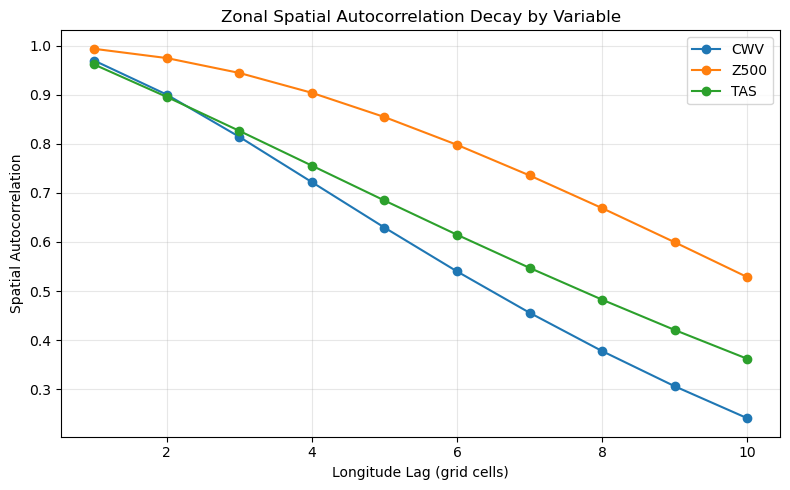

In [29]:
plt.figure(figsize=(8, 5))
variables = ["CWV", "Z500", "TAS"]

for v in da_prime['var'].values:
    plt.plot(
        spatial_corr_lon.coords['lag'].values, 
        spatial_corr_lon.sel(var=v).values, 
        marker='o', 
        label=variables[v]
    )

plt.xlabel('Longitude Lag (grid cells)')
plt.ylabel('Spatial Autocorrelation')
plt.title('Zonal Spatial Autocorrelation Decay by Variable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Assuming 'da' is your DataArray of shape (sample, lat, lon, var)
# Pre-center the data across the spatial domain for each sample
da_prime = da - da.mean(dim=['lat', 'lon'])

max_lag = 10  # Adjust based on grid resolution
lags = list(range(1, max_lag + 1))

# Compute correlation across all samples for each lag value
corrs_list = []
for lag in lags:
  
    corr_at_lag = xr.corr(da_prime, da_prime.shift(lat=lag), dim=['sample', 'lat', 'lon'])
    corrs_list.append(corr_at_lag)

# Concatenate along a new 'lag' dimension
# Shape becomes: (lag, var)
spatial_corr_lat = xr.concat(corrs_list, dim='lag').assign_coords(lag=lags)

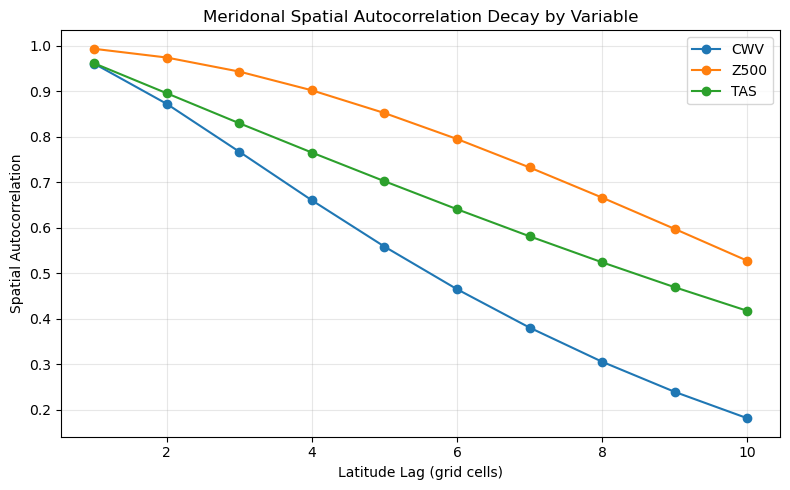

In [32]:
plt.figure(figsize=(8, 5))
variables = ["CWV", "Z500", "TAS"]

for v in da_prime['var'].values:
    plt.plot(
        spatial_corr_lat.coords['lag'].values, 
        spatial_corr_lat.sel(var=v).values, 
        marker='o', 
        label=variables[v]
    )

plt.xlabel('Latitude Lag (grid cells)')
plt.ylabel('Spatial Autocorrelation')
plt.title('Meridonal Spatial Autocorrelation Decay by Variable')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()